<a href="https://colab.research.google.com/github/dinhvhung/Machine_Learning/blob/nghia/XGBoost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
import pandas as pd

print("1. Đang yêu cầu kết nối với Google Drive...")
drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/ML_Projects/california_housing_FINAL_ready.csv'

print(f"\n2. Đang đọc dữ liệu từ: {file_path}...")
df = pd.read_csv(file_path)

print("📊 BÁO CÁO TỔNG QUAN BỘ DỮ LIỆU ĐÃ XỬ LÝ")

num_rows = df.shape[0]
num_cols = df.shape[1]

print(f"🔹 Tổng số dòng dữ liệu : {num_rows:,} (Khu dân cư)")
print(f"🔹 Tổng số thuộc tính   : {num_cols} (Cột)")

# Liệt kê danh sách tên các thuộc tính
print("\n📋 Danh sách chi tiết các thuộc tính (Features):")
for i, col in enumerate(df.columns, 1):
    print(f"   {i:02d}. {col}")

print("\n Dữ liệu đã sẵn sàng!")

1. Đang yêu cầu kết nối với Google Drive...
Mounted at /content/drive

2. Đang đọc dữ liệu từ: /content/drive/MyDrive/ML_Projects/california_housing_FINAL_ready.csv...
📊 BÁO CÁO TỔNG QUAN BỘ DỮ LIỆU ĐÃ XỬ LÝ
🔹 Tổng số dòng dữ liệu : 18,572 (Khu dân cư)
🔹 Tổng số thuộc tính   : 25 (Cột)

📋 Danh sách chi tiết các thuộc tính (Features):
   01. longitude
   02. latitude
   03. housing_median_age
   04. total_rooms
   05. total_bedrooms
   06. population
   07. households
   08. median_income
   09. median_house_value
   10. rooms_per_household
   11. bedrooms_per_room
   12. population_per_household
   13. ocean_proximity_<1H OCEAN
   14. ocean_proximity_INLAND
   15. ocean_proximity_ISLAND
   16. ocean_proximity_NEAR BAY
   17. ocean_proximity_NEAR OCEAN
   18. dist_to_real_school_km
   19. dist_to_real_hospital_km
   20. dist_to_real_supermarket_km
   21. dist_to_nearest_major_city
   22. avg_price_5km
   23. median_income_10nn
   24. wealth_ratio
   25. luxury_density_score

 Dữ liệu đã

In [ ]:
!pip install catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.6 MB/s eta 0:00:00


🚀 Khởi động chiến dịch kiểm thử với 4 Thông số cốt lõi...

🔄 Đang quét tỷ lệ 5:5...

🔄 Đang quét tỷ lệ 6:4...

🔄 Đang quét tỷ lệ 7:3...

🔄 Đang quét tỷ lệ 8:2...

🔄 Đang quét tỷ lệ 9:1...

🏆 BẢNG THÔNG SỐ ĐÁNH GIÁ CỐT LÕI

📍 KẾT QUẢ TẠI TỶ LỆ 5:5 (Train 50% - Test 50%):


,R² Score,RMSE ($),MAE ($),MAPE (%)
Thuật toán,,,,
1. Random Forest,0.8267,39922.0,25365.0,13.47
2. LightGBM,0.8504,37096.0,23495.0,12.55
3. XGBoost,0.8443,37842.0,23669.0,12.65
4. CatBoost,0.8475,37447.0,23588.0,12.58



📍 KẾT QUẢ TẠI TỶ LỆ 6:4 (Train 60% - Test 40%):


,R² Score,RMSE ($),MAE ($),MAPE (%)
Thuật toán,,,,
1. Random Forest,0.8320,39496.0,25032.0,13.37
2. LightGBM,0.8518,37091.0,23394.0,12.52
3. XGBoost,0.8500,37324.0,23284.0,12.53
4. CatBoost,0.8521,37060.0,23251.0,12.49



📍 KẾT QUẢ TẠI TỶ LỆ 7:3 (Train 70% - Test 30%):


,R² Score,RMSE ($),MAE ($),MAPE (%)
Thuật toán,,,,
1. Random Forest,0.8325,39561.0,25278.0,13.31
2. LightGBM,0.8535,36995.0,23467.0,12.38
3. XGBoost,0.8524,37135.0,23190.0,12.29
4. CatBoost,0.8521,37184.0,23442.0,12.39



📍 KẾT QUẢ TẠI TỶ LỆ 8:2 (Train 80% - Test 20%):


,R² Score,RMSE ($),MAE ($),MAPE (%)
Thuật toán,,,,
1. Random Forest,0.8380,39291.0,25146.0,13.09
2. LightGBM,0.8600,36518.0,23295.0,12.16
3. XGBoost,0.8593,36614.0,23040.0,12.08
4. CatBoost,0.8598,36542.0,23267.0,12.15



📍 KẾT QUẢ TẠI TỶ LỆ 9:1 (Train 90% - Test 10%):


,R² Score,RMSE ($),MAE ($),MAPE (%)
Thuật toán,,,,
1. Random Forest,0.8428,38881.0,24522.0,12.87
2. LightGBM,0.8652,36000.0,22712.0,11.90
3. XGBoost,0.8680,35621.0,22166.0,11.78
4. CatBoost,0.8645,36087.0,22633.0,11.94


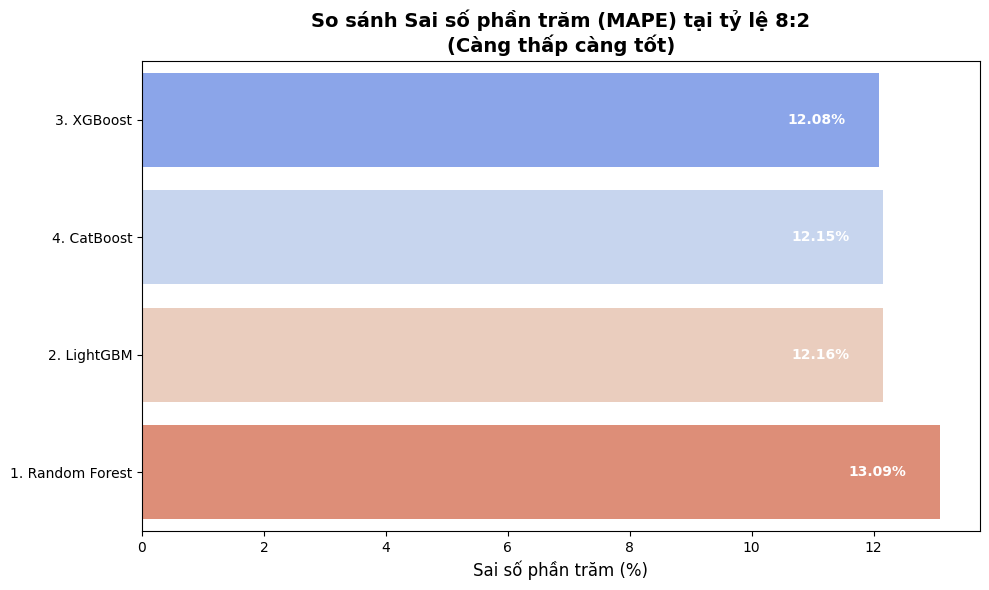

In [ ]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings('ignore')

print("🚀 Khởi động chiến dịch kiểm thử với 4 Thông số cốt lõi...")

# Hàm tính MAPE (Sai số phần trăm trung bình)
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

ratios = {'5:5': 0.5, '6:4': 0.4, '7:3': 0.3, '8:2': 0.2, '9:1': 0.1}

models = {
    '1. Random Forest': RandomForestRegressor(n_estimators=300, max_depth=10, random_state=42, n_jobs=-1),
    '2. LightGBM': lgb.LGBMRegressor(n_estimators=300, learning_rate=0.05, max_depth=10, random_state=42, n_jobs=-1, verbose=-1),
    '3. XGBoost': xgb.XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=10, random_state=42, n_jobs=-1),
    '4. CatBoost': CatBoostRegressor(iterations=300, learning_rate=0.05, depth=10, random_state=42, verbose=False)
}

X = df.drop('median_house_value', axis=1)
X.columns = X.columns.str.replace(r'[<\[\]]', '_', regex=True)

y = df['median_house_value']

results = []

# Vòng lặp tính toán
for label, test_size in ratios.items():
    print(f"\n🔄 Đang quét tỷ lệ {label}...")
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42)

    y_train_log = np.log1p(y_train)
    y_test_log = np.log1p(y_test)

    for name, model in models.items():
        model.fit(X_train, y_train_log)

        y_pred_real = np.expm1(model.predict(X_test))
        y_test_real = np.expm1(y_test_log)

        r2 = r2_score(y_test_real, y_pred_real)
        rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
        mae = mean_absolute_error(y_test_real, y_pred_real)
        mape = mean_absolute_percentage_error(y_test_real, y_pred_real)

        results.append({
            'Tỷ lệ': label,
            'Thuật toán': name,
            'R² Score': round(r2, 4),
            'RMSE ($)': round(rmse, 0),
            'MAE ($)': round(mae, 0),
            'MAPE (%)': round(mape, 2)
        })

results_df = pd.DataFrame(results)

print("\n" + "="*80)
print("🏆 BẢNG THÔNG SỐ ĐÁNH GIÁ CỐT LÕI")
print("="*80)

# Gom nhóm theo Tỷ lệ để dễ nhìn
for label in ratios.keys():
    print(f"\n📍 KẾT QUẢ TẠI TỶ LỆ {label} (Train {int((1-ratios[label])*100)}% - Test {int(ratios[label]*100)}%):")
    display_df = results_df[results_df['Tỷ lệ'] == label].drop('Tỷ lệ', axis=1).set_index('Thuật toán')
    display(display_df)

plt.figure(figsize=(10, 6))
df_82 = results_df[results_df['Tỷ lệ'] == '8:2'].sort_values('MAPE (%)')

sns.barplot(x='MAPE (%)', y='Thuật toán', data=df_82, palette='coolwarm')
plt.title('So sánh Sai số phần trăm (MAPE) tại tỷ lệ 8:2\n(Càng thấp càng tốt)', fontsize=14, fontweight='bold')
plt.xlabel('Sai số phần trăm (%)', fontsize=12)
plt.ylabel('')

for index, value in enumerate(df_82['MAPE (%)']):
    plt.text(value - 1.5, index, f"{value}%", color='white', fontweight='bold', va='center')

plt.tight_layout()
plt.show()

In [ ]:
!pip install shap -q

🔄 Đang càn quét chiến trường tỷ lệ 5:5...
🔄 Đang càn quét chiến trường tỷ lệ 6:4...
🔄 Đang càn quét chiến trường tỷ lệ 7:3...
🔄 Đang càn quét chiến trường tỷ lệ 8:2...
🔄 Đang càn quét chiến trường tỷ lệ 9:1...

✅ ĐÃ HOÀN TẤT TÍNH TOÁN 20 KỊCH BẢN!

🏆 BẢNG XẾP HẠNG CHÂN LÝ TỐI THƯỢNG (TRUNG BÌNH 20 KỊCH BẢN)


,RF_5:5,XGB_8:2,Cat_9:1,Ultimate_Consensus (%)
Feature,,,,
avg_price_5km,64.84,53.02,37.25,51.38
median_income,16.38,12.72,14.58,13.84
population_per_household,4.72,6.46,7.99,6.45
rooms_per_household,3.18,4.61,4.42,4.24
bedrooms_per_room,2.66,3.77,4.89,3.80
luxury_density_score,0.85,2.62,3.79,2.47
dist_to_nearest_major_city,1.20,2.16,3.19,2.37
housing_median_age,0.99,2.09,2.21,1.86
median_income_10nn,0.64,1.18,2.80,1.72


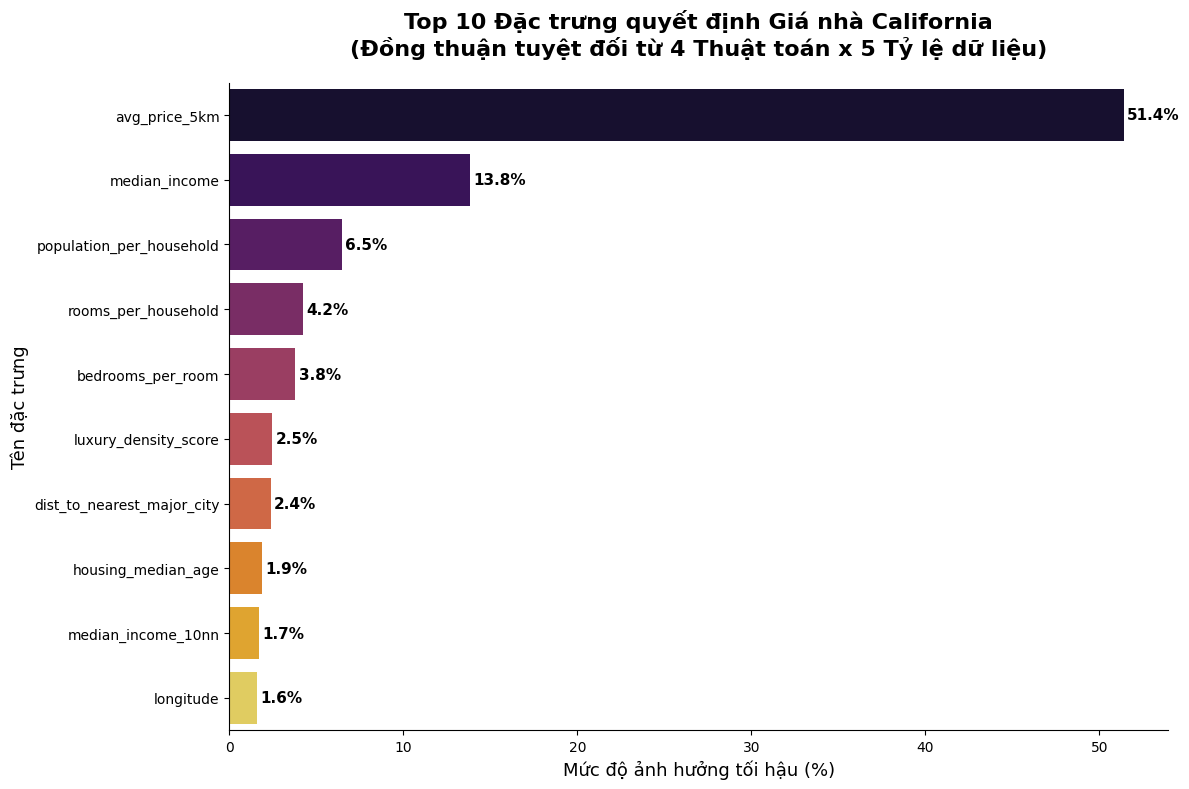

In [ ]:
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

import warnings
warnings.filterwarnings('ignore')

# 1. Cấu hình kịch bản
ratios = {'5:5': 0.5, '6:4': 0.4, '7:3': 0.3, '8:2': 0.2, '9:1': 0.1}

models = {
    'RF': RandomForestRegressor(n_estimators=300, max_depth=10, random_state=42, n_jobs=-1),
    'LGBM': lgb.LGBMRegressor(n_estimators=300, learning_rate=0.05, max_depth=10, random_state=42, n_jobs=-1, verbose=-1),
    'XGB': xgb.XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=10, random_state=42, n_jobs=-1),
    'Cat': CatBoostRegressor(iterations=300, learning_rate=0.05, depth=10, random_state=42, verbose=False)
}

# Đổi tên cột tránh lỗi XGBoost
X = df.drop('median_house_value', axis=1)
X.columns = X.columns.str.replace(r'[<\[\]]', '_', regex=True)
y = df['median_house_value']

master_shap_df = pd.DataFrame({'Feature': X.columns}).set_index('Feature')

# 2. VÒNG LẶP KÉP HỦY DIỆT
for label, test_size in ratios.items():
    print(f"🔄 Đang càn quét chiến trường tỷ lệ {label}...")
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42)
    y_train_log = np.log1p(y_train)

    X_test_sample = X_test.sample(n=min(20000, len(X_test)), random_state=42)

    for name, model in models.items():
        # Huấn luyện
        model.fit(X_train, y_train_log)

        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_test_sample)


        mean_abs_shap = np.abs(shap_values).mean(axis=0)
        normalized_shap = (mean_abs_shap / mean_abs_shap.sum()) * 100

        col_name = f"{name}_{label}"
        master_shap_df[col_name] = normalized_shap

print("\n✅ ĐÃ HOÀN TẤT TÍNH TOÁN 20 KỊCH BẢN!")

master_shap_df['Ultimate_Consensus (%)'] = master_shap_df.mean(axis=1)

top_features = master_shap_df.sort_values('Ultimate_Consensus (%)', ascending=False).head(10)

print("\n" + "="*80)
print("🏆 BẢNG XẾP HẠNG CHÂN LÝ TỐI THƯỢNG (TRUNG BÌNH 20 KỊCH BẢN)")
print("="*80)
display(np.round(top_features[['RF_5:5', 'XGB_8:2', 'Cat_9:1', 'Ultimate_Consensus (%)']], 2))

plt.figure(figsize=(12, 8))
sns.barplot(
    x=top_features['Ultimate_Consensus (%)'],
    y=top_features.index,
    palette='inferno'
)

plt.title('Top 10 Đặc trưng quyết định Giá nhà California\n(Đồng thuận tuyệt đối từ 4 Thuật toán x 5 Tỷ lệ dữ liệu)',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Mức độ ảnh hưởng tối hậu (%)', fontsize=13)
plt.ylabel('Tên đặc trưng', fontsize=13)

# Ghi số liệu cực nét lên biểu đồ
for index, value in enumerate(top_features['Ultimate_Consensus (%)']):
    plt.text(value + 0.2, index, f"{value:.1f}%", color='black', fontweight='bold', va='center', fontsize=11)

# Tinh chỉnh hiển thị
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np

# 1. Ép hệ thống hiển thị tối đa tất cả các cột và dòng, không bị ẩn bằng dấu (...)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', 2000)

# 2. Sắp xếp lại bảng từ cao xuống thấp dựa trên 'Chân lý tối hậu'
full_report_df = master_shap_df.sort_values('Ultimate_Consensus (%)', ascending=False)

# Làm tròn 2 chữ số thập phân cho đẹp mắt
full_report_df_rounded = np.round(full_report_df, 2)

print("\n" + "="*120)
print("📊 BẢNG CHI TIẾT ĐỘ QUAN TRỌNG ĐẶC TRƯNG QUA 20 KỊCH BẢN TÍNH TOÁN (%)")
print("="*120)
display(full_report_df_rounded)

# 3. LƯU BẢNG KHỔNG LỒ NÀY RA FILE CSV
# Bạn hãy điều chỉnh lại đường dẫn thư mục Drive nếu cần nhé
save_path = '/content/drive/MyDrive/ML_Projects/SHAP_20_Scenarios_Full_Report.csv'
full_report_df_rounded.to_csv(save_path)

print("\n" + "-"*50)
print(f"✅ XUẤT SẮC! Đã lưu toàn bộ bảng chi tiết ra file tại:")
print(f"👉 {save_path}")


📊 BẢNG CHI TIẾT ĐỘ QUAN TRỌNG ĐẶC TRƯNG QUA 20 KỊCH BẢN TÍNH TOÁN (%)


,RF_5:5,LGBM_5:5,XGB_5:5,Cat_5:5,RF_6:4,LGBM_6:4,XGB_6:4,Cat_6:4,RF_7:3,LGBM_7:3,XGB_7:3,Cat_7:3,RF_8:2,LGBM_8:2,XGB_8:2,Cat_8:2,RF_9:1,LGBM_9:1,XGB_9:1,Cat_9:1,Ultimate_Consensus (%)
Feature,,,,,,,,,,,,,,,,,,,,,
avg_price_5km,64.84,50.40,53.790001,36.29,64.76,50.73,53.830002,36.05,64.91,50.60,52.93,34.53,64.71,51.02,53.02,37.86,65.02,52.01,53.049999,37.25,51.38
median_income,16.38,11.26,12.350000,13.31,17.19,11.92,12.980000,13.55,17.22,11.49,12.92,14.11,17.52,11.43,12.72,14.93,16.86,11.33,12.690000,14.58,13.84
population_per_household,4.72,6.65,6.230000,7.99,4.85,6.63,6.200000,7.57,4.84,6.74,6.35,8.08,4.98,6.77,6.46,7.74,4.99,6.81,6.510000,7.99,6.45
rooms_per_household,3.18,5.79,4.920000,3.92,2.69,5.29,4.770000,3.85,2.67,5.69,4.52,4.05,2.42,5.29,4.61,4.52,2.49,5.16,4.610000,4.42,4.24
bedrooms_per_room,2.66,3.86,3.760000,6.12,2.21,3.68,3.380000,5.80,2.28,3.78,3.68,5.54,2.20,3.90,3.77,4.49,2.31,3.98,3.730000,4.89,3.80
luxury_density_score,0.85,2.14,1.620000,4.50,1.04,2.39,1.990000,4.21,1.15,2.57,2.35,5.24,1.29,2.56,2.62,2.95,1.32,2.38,2.440000,3.79,2.47
dist_to_nearest_major_city,1.20,2.52,2.630000,3.28,1.25,2.27,2.460000,3.76,1.00,2.67,2.32,3.46,1.10,2.46,2.16,3.61,1.12,2.56,2.460000,3.19,2.37
housing_median_age,0.99,1.99,1.910000,2.28,1.03,2.08,1.990000,2.35,1.04,1.99,2.00,2.27,1.19,2.04,2.09,2.23,1.30,2.11,2.120000,2.21,1.86
median_income_10nn,0.64,1.51,1.240000,3.93,0.63,1.47,1.150000,4.34,0.53,1.59,1.13,4.35,0.57,1.46,1.18,3.10,0.48,1.25,1.090000,2.80,1.72



--------------------------------------------------
✅ XUẤT SẮC! Đã lưu toàn bộ bảng chi tiết ra file tại:
👉 /content/drive/MyDrive/ML_Projects/SHAP_20_Scenarios_Full_Report.csv
